# Analytical Dye Misidentification Analysis

This section uses the **analytical approach** to characterize measurement noise:

1. **Extract fixed means** from highest-photon data (200k+ photons) - represents true dye signatures
2. **Fit covariances** at each photon level with fixed means (Soft EM) - characterizes measurement uncertainty
3. **Analytically calculate** misidentification rates from distribution overlap (Monte Carlo integration)

This is superior to the empirical approach because it:
- Separates signal (means = dye properties) from noise (covariances = measurement uncertainty)
- Directly models the noise at each photon level
- Provides stable, interpretable predictions of error rates

## Example Analyses with the New Databases

## Database Outputs

Three databases are created:

1. **Single Molecule Database** (`sm_db`): One row per molecule with averaged parameters
   - Includes `fov_index` and `fov_name` columns to track origin
   - `molecular_index` is globally unique across all FOVs

2. **Single Frame Database** (`sf_db`): One row per localization  
   - Includes `molecular_index` to link back to parent molecule
   - Includes `fov_index` and `fov_name`

3. **Photon Accumulation Database** (`pa_db`): One row per molecule per accumulated frame
   - Shows how A_R, A_G, A_B evolve as photons accumulate
   - Enables precision vs photon count analysis

# Multi-FOV Analysis with New Wrapper Functions

The new `analyze_multi_fov_dataset()` function provides a complete workflow for:
1. Processing multiple FOV localization files
2. Tracking which FOV each molecule came from
3. Building photon accumulation databases for precision analysis

This replaces the manual per-file processing shown above with a single function call.

In [1]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import pandas as pd
import polars as pl
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

import sys

sys.path.append("..")

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import PlottingBase

plotter = PlottingBase.PublicationPlotter(dark_background=False)

from src import ImageAnalysisFunctions

I_AF = ImageAnalysisFunctions.Image_Analysis_Functions()

from src import sCMOSFunctions

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import SpectralFunctions

S_F = SpectralFunctions.Spectral_Funcs()

from src import MaskFunctions

M_F = MaskFunctions.Mask_Functions()

from src import SpotDetectionFunctions

SD_F = SpotDetectionFunctions.SpotDetection_Functions()

from src import SR_Functions

SRes_F = SR_Functions.SuperRes_Functions()

from src import HelperFunctions

H_F = HelperFunctions.Helper_Functions()

from src import SM_extractionfunctions

SM_E = SM_extractionfunctions.extract_SMs()

from src.DriftCorrectionFunctions import (
    Drift_Correction_Functions,
    DriftMethod,
    DriftParameters,
    DriftResult,
)

import types

smoothing_function = types.SimpleNamespace()
smoothing_function.args = {"sigma": 1.5}
smoothing_function.extent = 1.5
smoothing_function.smoothing_function = sCMOS.gaussian_filter_stack
smoothing_function.data_arg = "image"

In [2]:
data_folder = "../Camera_Calibrations/Ximea_Camera/"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))
R, G, B, wavelength = S_F.getpixelefficiency()

In [3]:
objective_T = S_F.getobjectiveefficiency(wavelength)

In [4]:
wavelength = wavelength
pixel_QYs = np.vstack([B, G, R])

In [5]:
dye_data_folders = np.array([r"C:\Users\kbhc756\temp_data\20251125_btc_analysis\ATTO647N_QDOT800\10mw"])

In [6]:
localisation_files = H_F.file_search(dye_data_folders[0], ".h5", "Pos")

In [7]:
localisation_files

['C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_000.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_001.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_002.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_003.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos001_000.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos001_001.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos001_002.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125

In [8]:
len(localisation_files)

16

### define some common parameters

In [9]:
min_cluster_size = 5
chi_val = 2
max_localisation_error = 1.0
min_photons = 100
max_photons = 1e6
max_distance = 1

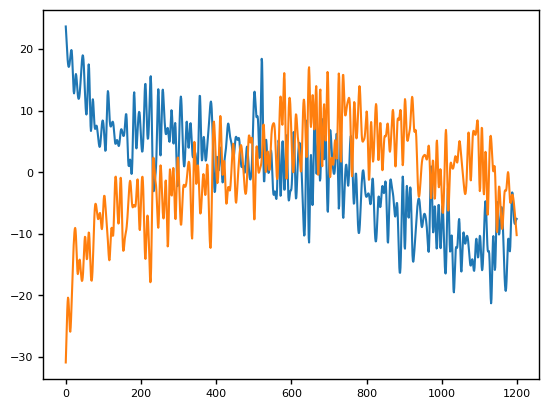

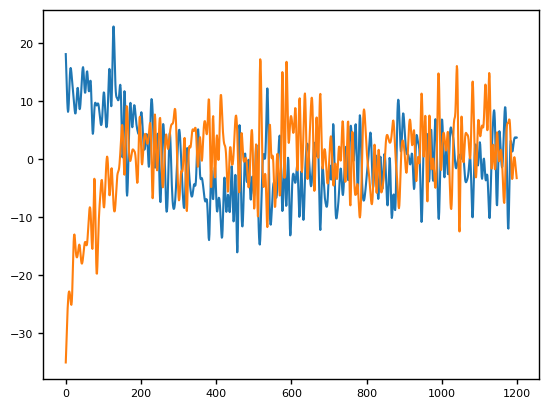

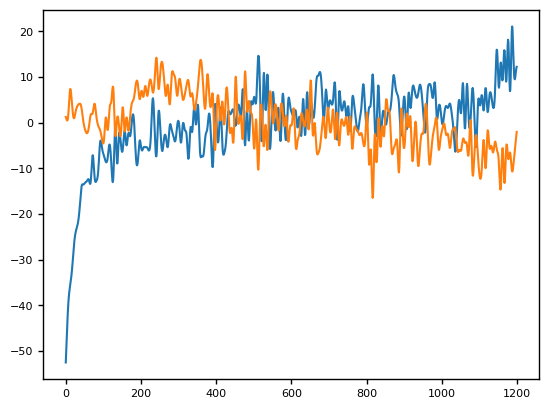

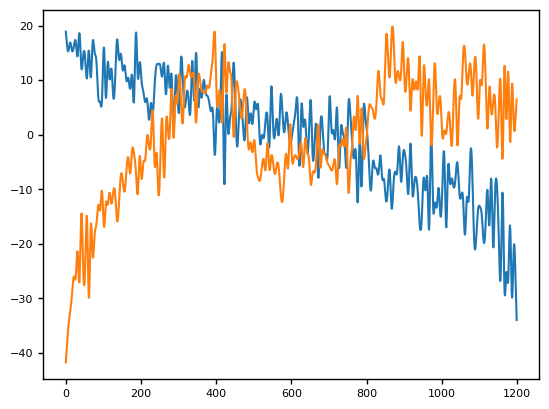

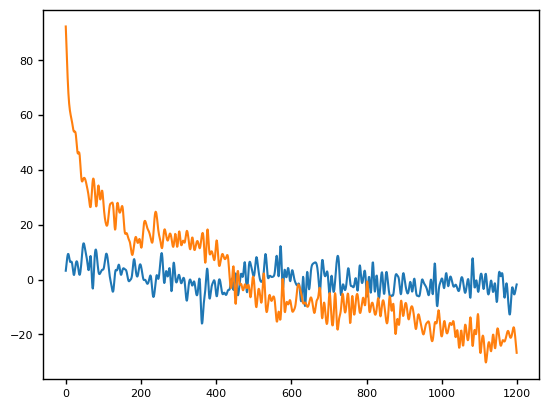

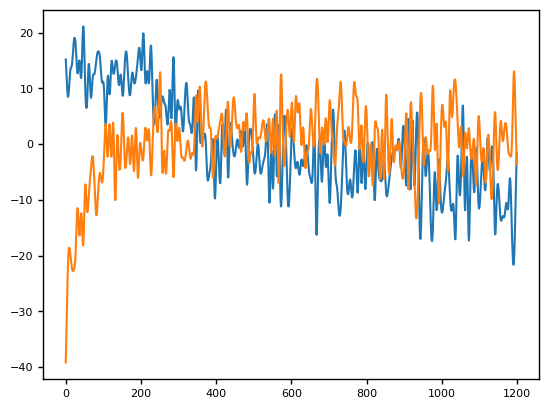

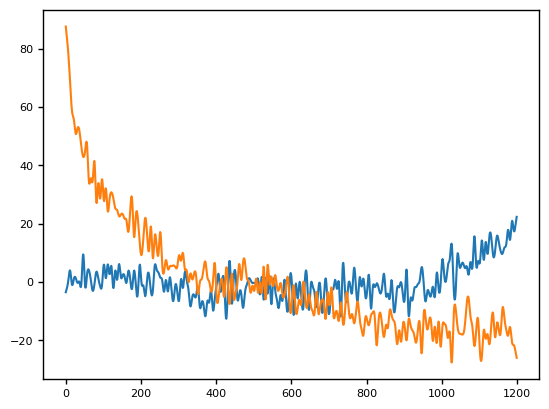

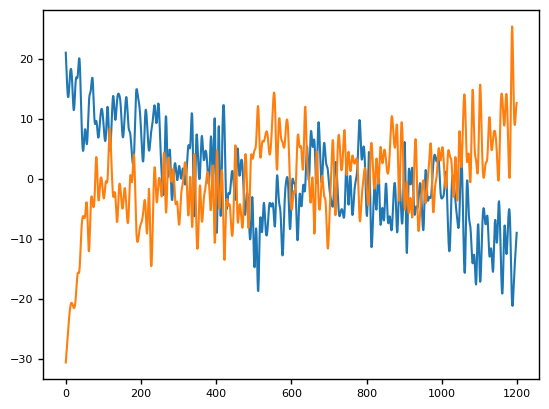

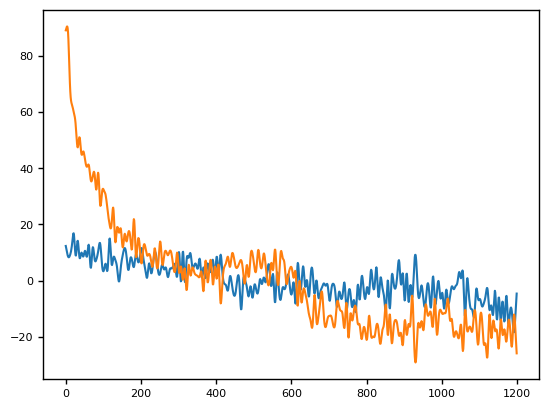

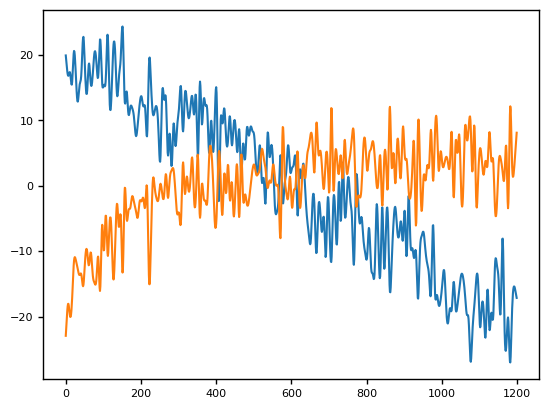

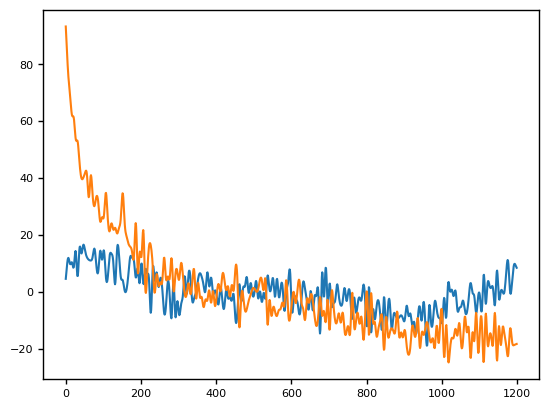

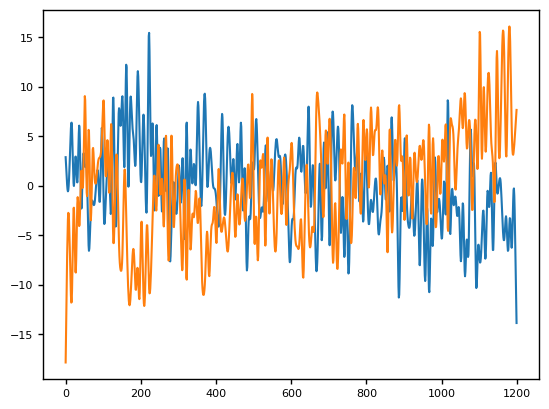

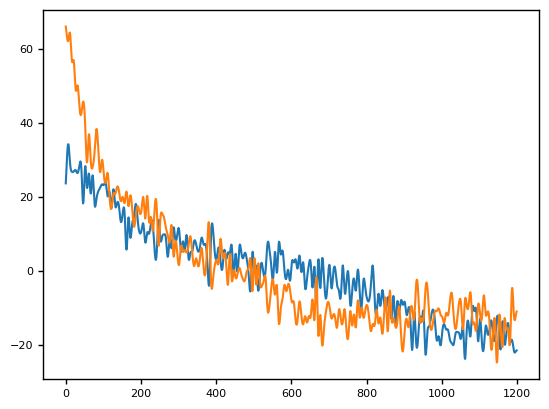

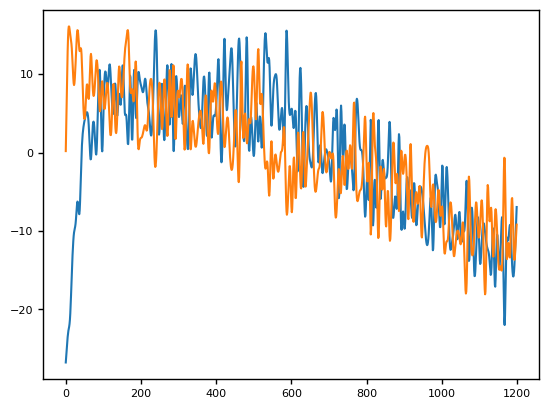

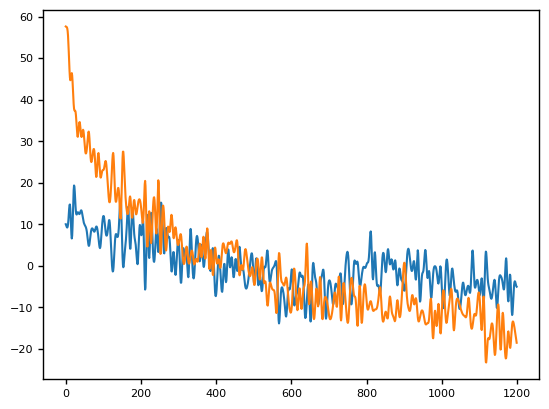

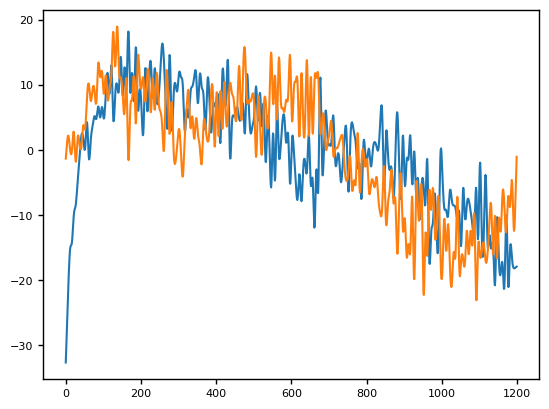

In [10]:
for i in np.arange(16):
    test_locs = pd.read_hdf(localisation_files[i])
    DCF = Drift_Correction_Functions()
    metadata_files = H_F.file_search(dye_data_folders[0], "metadata", "")
    x_coord, y_coord, width, height = IO.metadata_reader_imageJ(metadata_files[0])
    n_frames = IO.metadata_nframes_reader_imageJ(metadata_files[0])
    method = 'aim'
    info = [{
        "Width": float(width),
        "Height": float(height),
        "Frames": float(n_frames),
        "Pixelsize": 69.0  # nm per pixel
    }]
    
    params = {
                        "segmentation": 5,  # Larger segments for AIM
                        "intersect_d": 0.5,   # Intersection distance
                        "roi_r": 2.0          # Search radius
                    }
    corrected_locs, drift_result = DCF.undrift(
                    test_locs.to_records(index=False), info, method=method, **params
                )
    corrected_locs = pd.DataFrame(corrected_locs)
    
    plt.plot(drift_result.drift_x*69)
    plt.plot(drift_result.drift_y*69)
    plt.show()
    
    # save corrected localisations
    IO._write_h5_database(
        corrected_locs,
        os.path.join(
            dye_data_folders[0], localisation_files[i].split(".h5")[0] + "_undrifted_locs.h5"
        ),
        normalise_photons=False,
        append=False
    )

In [6]:
localisation_files = H_F.file_search(dye_data_folders[0], "_undrifted_locs.h5", "Pos")

In [7]:
localisation_files

['C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_000_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_001_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_002_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos000_003_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos001_000_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_DM405488561638_NF_SP_1_MMStack_1-Pos001_001_undrifted_locs.h5',
 'C:\\Users\\kbhc756\\temp_data\\20251125_btc_analysis\\ATTO647N_QDOT800\\10mw\\10mW638_

In [13]:
# Example 1: Complete multi-FOV analysis with photon accumulation
# This single function call does everything:
# - Clusters molecules in each FOV
# - Tracks FOV origin for each molecule
# - Builds photon accumulation database
# - Saves all results to disk

sm_db, sf_db, pa_db = SM_E.analyse_multi_fov_dataset(
    localisation_files,  # List of all FOV .h5 files
    clustering_method="DBSCAN",
    build_accumulation=True,
    min_cluster_size=min_cluster_size,
    max_localisation_error=max_localisation_error,
    chi_val=chi_val,
    min_photons=min_photons,
    max_photons=max_photons,
    output_folder=dye_data_folders[0],
    output_prefix="dye_mixture_analysis",
    verbose=True
)

Multi-FOV Single Molecule Analysis
 45757 localizations... Found 157 molecules_NF_SP_1_MMStack_1-Pos000_000_undrifted_locs.h5)...
 42369 localizations... Found 180 molecules_NF_SP_1_MMStack_1-Pos000_001_undrifted_locs.h5)...
 53987 localizations... Found 233 molecules_NF_SP_1_MMStack_1-Pos000_002_undrifted_locs.h5)...
 57676 localizations... Found 227 molecules_NF_SP_1_MMStack_1-Pos000_003_undrifted_locs.h5)...
 62121 localizations... Found 258 molecules_NF_SP_1_MMStack_1-Pos001_000_undrifted_locs.h5)...
 46824 localizations... Found 164 molecules_NF_SP_1_MMStack_1-Pos001_001_undrifted_locs.h5)...
 49019 localizations... Found 175 molecules_NF_SP_1_MMStack_1-Pos001_002_undrifted_locs.h5)...
 48751 localizations... Found 225 molecules_NF_SP_1_MMStack_1-Pos001_003_undrifted_locs.h5)...
 60146 localizations... Found 216 molecules_NF_SP_1_MMStack_1-Pos002_000_undrifted_locs.h5)...
 61808 localizations... Found 229 molecules8_NF_SP_1_MMStack_1-Pos002_001_undrifted_locs.h5)...
 55360 localiz

In [8]:
folder = dye_data_folders[0]
sm_db = pd.read_hdf(os.path.join(folder, 'dye_mixture_analysis_single_molecules.h5'))
sf_db = pd.read_hdf(os.path.join(folder, 'dye_mixture_analysis_single_frames.h5'))
pa_db = pd.read_hdf(os.path.join(folder, 'dye_mixture_analysis_photon_accumulation.h5'))

In [9]:
len(sm_db)

3676

In [16]:
molecular_indices = np.unique(sm_db['molecular_index'])

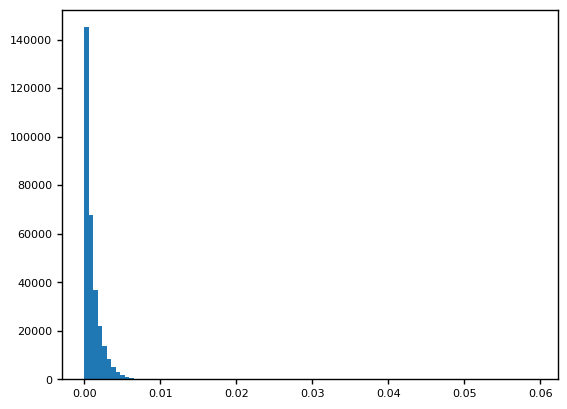

In [17]:
plt.hist(sf_db['A_G_err'], 100);
plt.show()

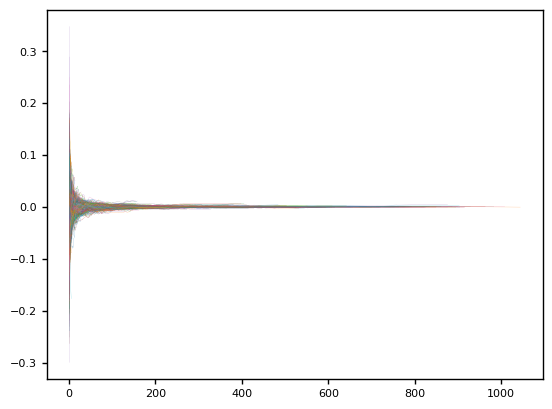

In [18]:
for index in molecular_indices:
    test = pa_db[pa_db['molecular_index'] == index]
    plt.plot(test['frames_accumulated'], test['A_G']-np.median(test['A_G'].to_numpy()), lw=0.1)
plt.show()

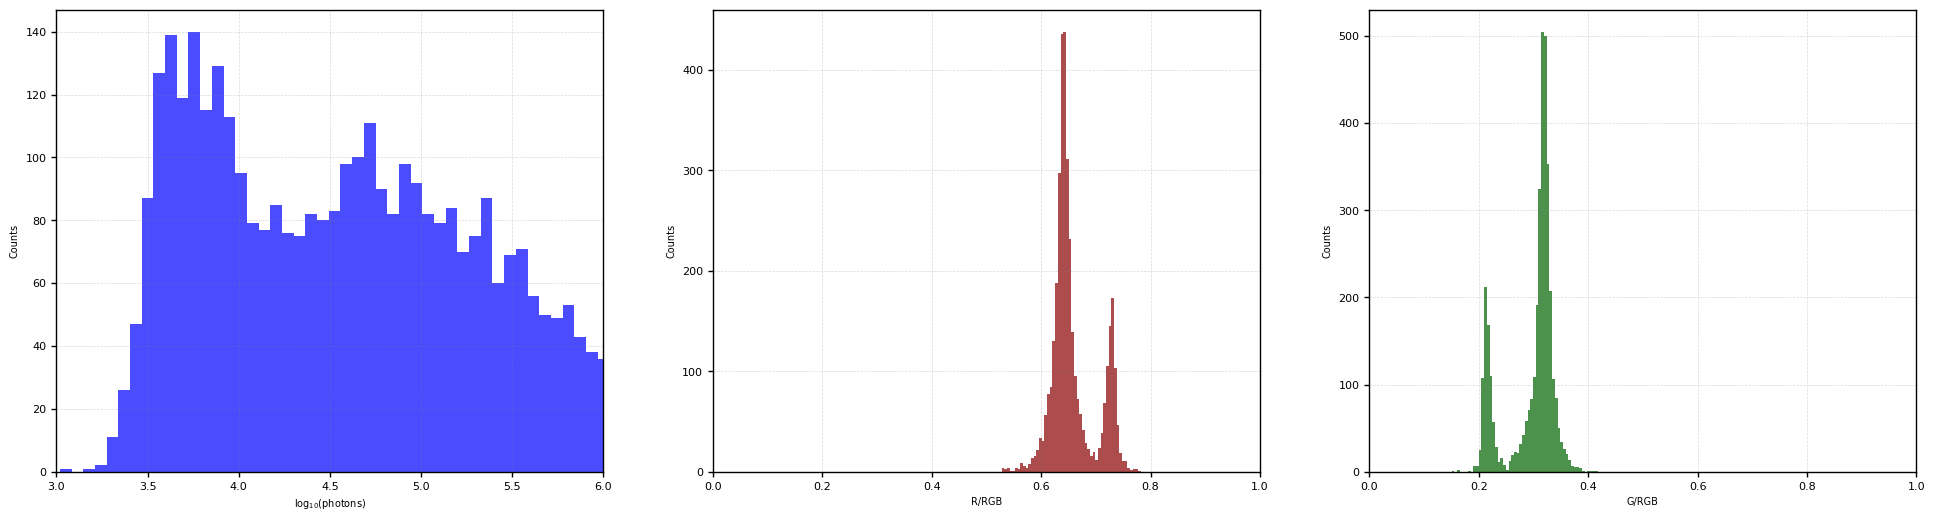

In [21]:
fig, axs = plotter.create_subplots(ncols=3)


bins = np.histogram_bin_edges(np.log10(sm_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sm_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)')


bins = np.histogram_bin_edges(sm_db['A_R'].to_numpy(), 'fd')
axs[1] = plotter.histogram_plot(axs[1], sm_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
bins = np.histogram_bin_edges(sm_db['A_G'].to_numpy(), 'fd')
axs[2] = plotter.histogram_plot(axs[2], sm_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')

axs[0].set_xlim([3, 6])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
folder = r'C:\Users\kbhc756\temp_data\20251125_btc_analysis\ATTO647N_QDOT800\10mw'
plt.savefig(os.path.join(folder, 'Dye_Mixtures_perMolecule.svg'), dpi=600, format='svg')

plt.show()

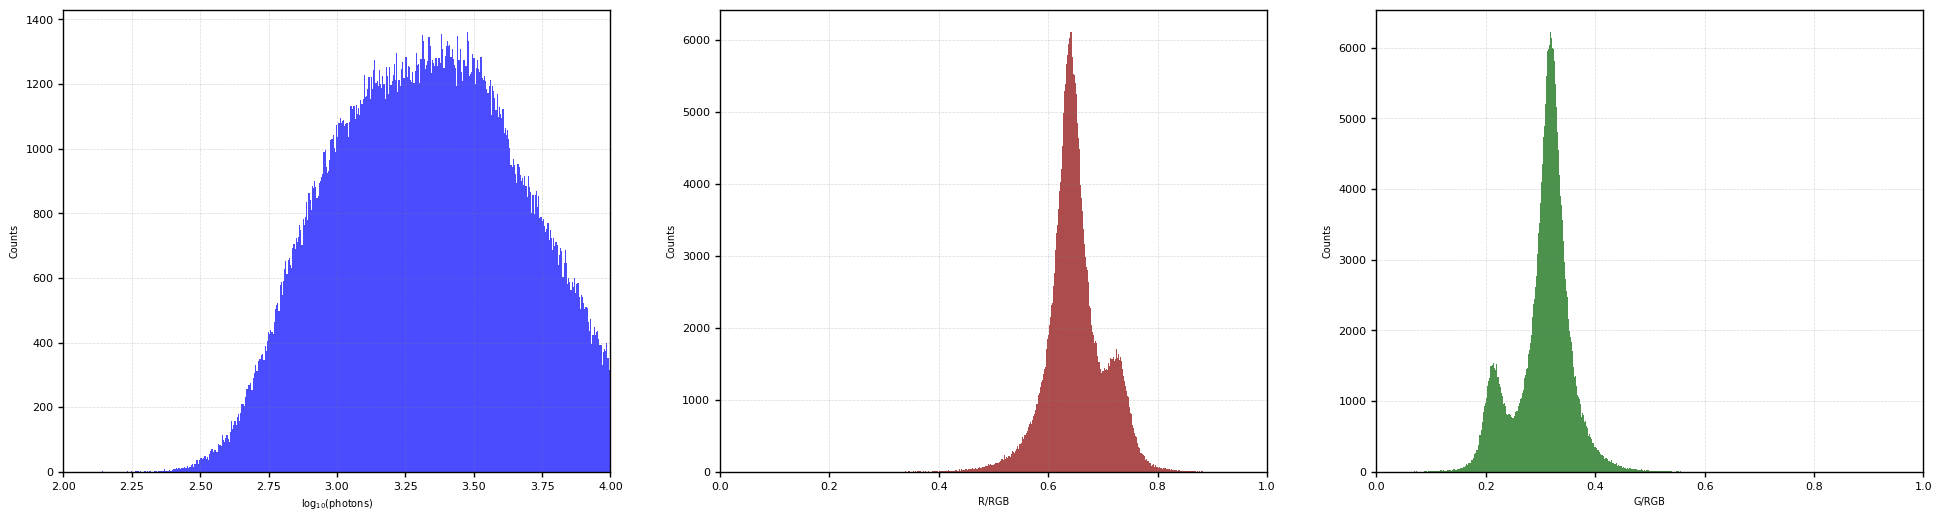

In [22]:
fig, axs = plotter.create_subplots(ncols=3)


bins = np.histogram_bin_edges(np.log10(sf_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sf_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)')


bins = np.histogram_bin_edges(sf_db['A_R'].to_numpy(), 'fd')
axs[1] = plotter.histogram_plot(axs[1], sf_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
bins = np.histogram_bin_edges(sf_db['A_G'].to_numpy(), 'fd')
axs[2] = plotter.histogram_plot(axs[2], sf_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')

axs[0].set_xlim([2, 4])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])
plt.savefig(os.path.join(folder, 'Dye_Mixtures_perFrame.svg'), dpi=600, format='svg')

plt.show()

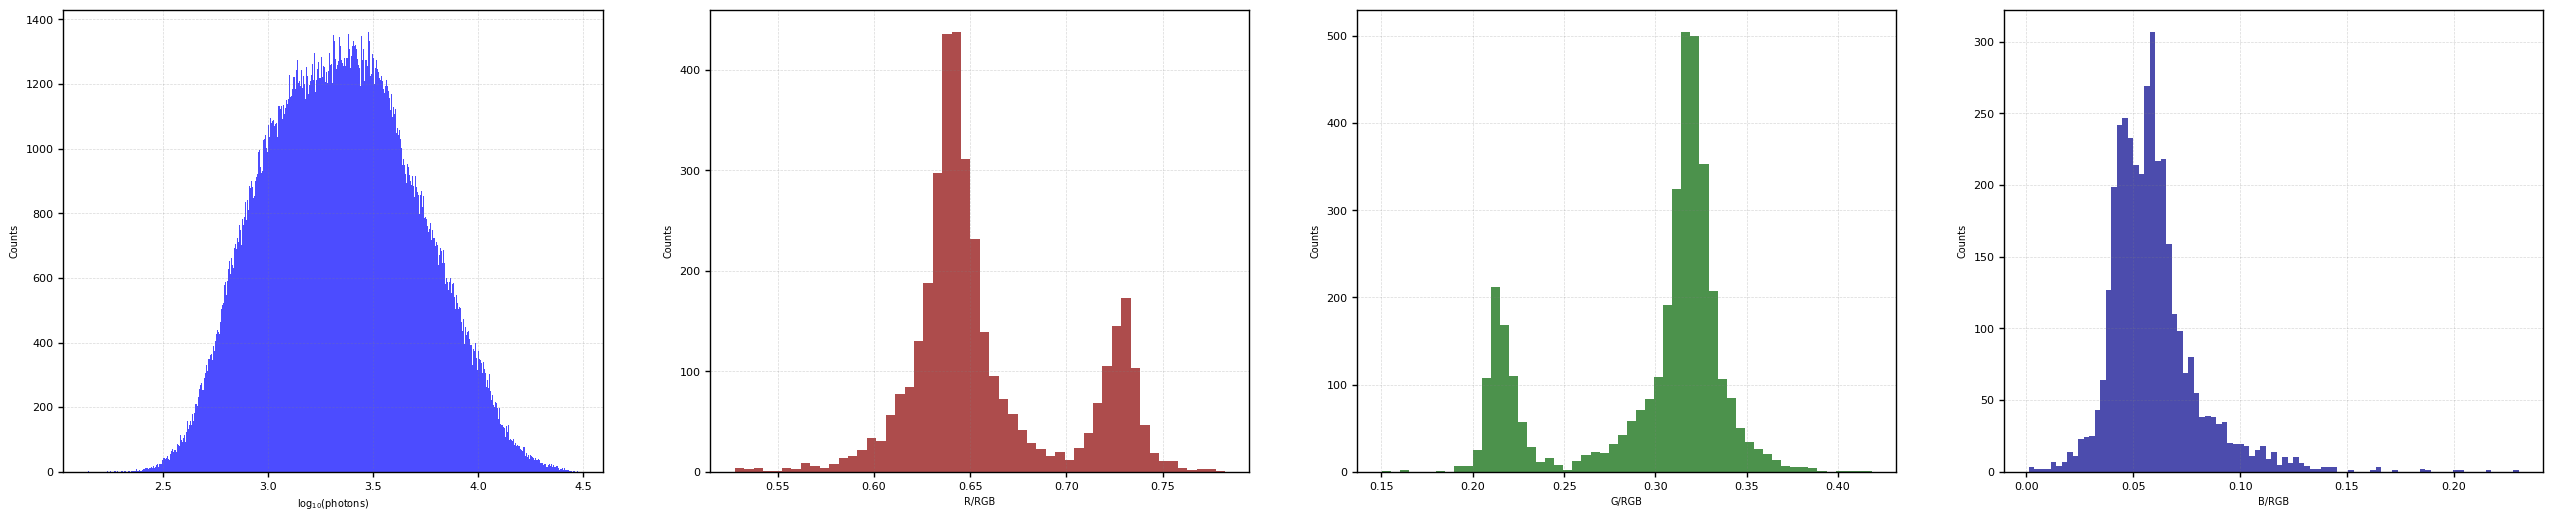

In [25]:
fig, axs = plotter.create_subplots(ncols=4)


bins = np.histogram_bin_edges(np.log10(sf_db['photons'].to_numpy()), 'sqrt')
axs[0] = plotter.histogram_plot(axs[0], np.log10(sf_db['photons']), bins, density=False, 
                                xlabel=r'log$_{10}$(photons)')


bins = np.histogram_bin_edges(sm_db['A_R'].to_numpy(), 'fd')
axs[1] = plotter.histogram_plot(axs[1], sm_db['A_R'], bins, 
                                color='darkred',
                               xlabel='R/RGB')
bins = np.histogram_bin_edges(sm_db['A_G'].to_numpy(), 'fd')
axs[2] = plotter.histogram_plot(axs[2], sm_db['A_G'], bins, 
                                color='darkgreen',
                               xlabel='G/RGB')
bins = np.histogram_bin_edges(sm_db['A_B'].to_numpy(), 'fd')

axs[3] = plotter.histogram_plot(axs[3], sm_db['A_B'], bins, 
                                color='darkblue',
                               xlabel='B/RGB')

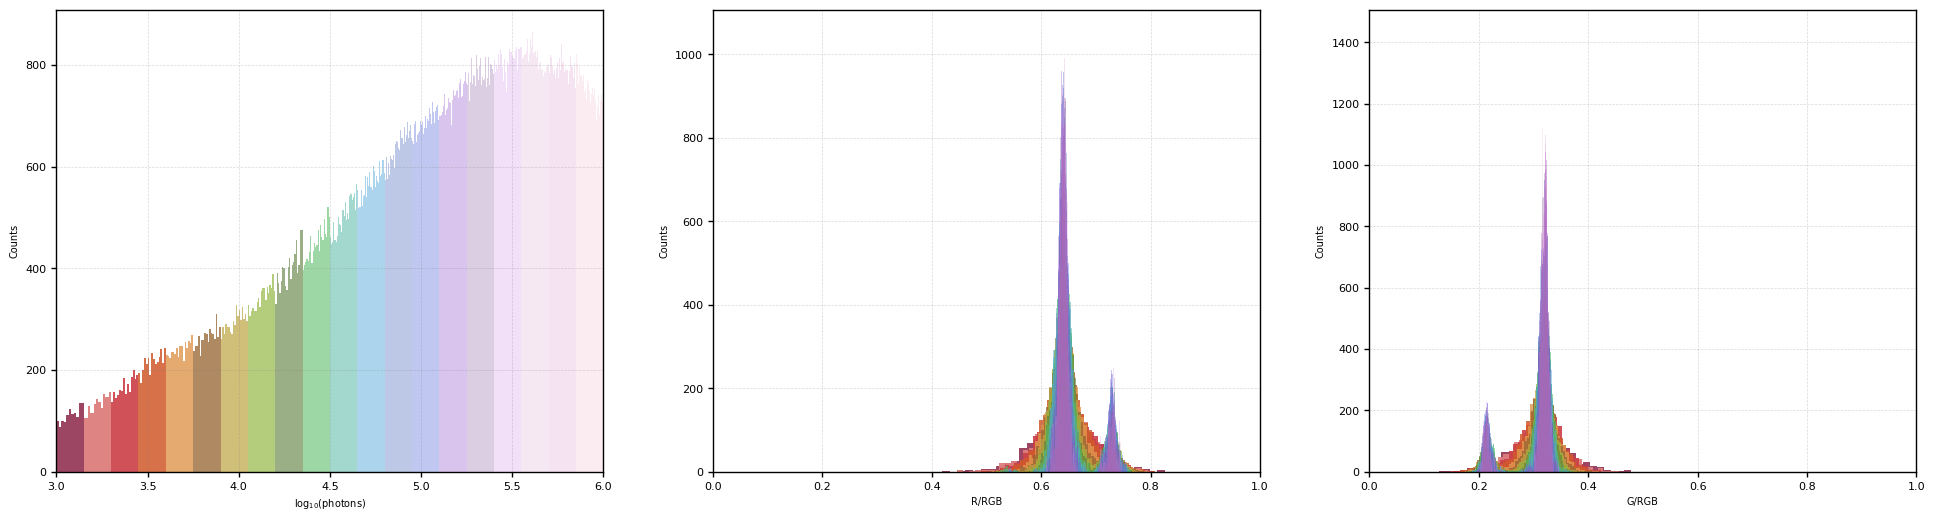

In [26]:
fig, axs = plotter.create_subplots(ncols=3)

filter_levels = np.logspace(3, 6, 21)

cs = ["#9d4663",
"#dd7e7d",
"#cb3f46",
"#d05a2b",
"#df974e",
"#966531",
"#bea643",
"#8fb43c",
"#5c7e3c",
"#55ba63",
"#4eb5a0",
"#52a7d8",
"#6880c5",
"#5c6fda",
"#9052ca",
"#84549c",
"#cc7de4",
"#d18cc6",
"#c548a8",
"#d94882"]

alpha_gradient = np.linspace(1, 0.1, 20)

for i in np.arange(len(filter_levels[:-1])):
    filtered = pa_db[
          (pa_db['photons_accumulated'] >= filter_levels[i]) &
          (pa_db['photons_accumulated'] < filter_levels[i+1])
      ]
    bins = np.histogram_bin_edges(np.log10(filtered['photons_accumulated'].to_numpy()), 'fd')
    axs[0] = plotter.histogram_plot(axs[0], np.log10(filtered['photons_accumulated']), bins, density=False, 
                                    color=cs[i], xlabel=r'log$_{10}$(photons)',
                                   alpha=alpha_gradient[i])

    
    bins = np.histogram_bin_edges(filtered['A_R'].to_numpy(), 'fd')
    axs[1] = plotter.histogram_plot(axs[1], filtered['A_R'], bins, 
                                    alpha=alpha_gradient[i], color=cs[i],
                                   xlabel='R/RGB')
    bins = np.histogram_bin_edges(filtered['A_G'].to_numpy(), 'fd')
    axs[2] = plotter.histogram_plot(axs[2], filtered['A_G'], bins, 
                                    alpha=alpha_gradient[i], color=cs[i],
                                   xlabel='G/RGB')

axs[0].set_xlim([3, 6])
axs[1].set_xlim([0., 1])
axs[2].set_xlim([0., 1])

plt.savefig(os.path.join(folder, 'Dye_Mixtures_vs_Photons.svg'), dpi=600, format='svg')
plt.show()

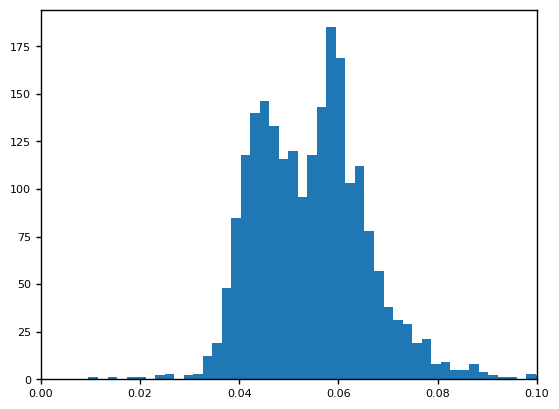

In [16]:
plt.hist(sm_db['A_B'][sm_db['photons'] > 20000][sm_db['A_R'] > 0.4][sm_db['A_G'] > 0.175], 100);
plt.xlim([0,0.1])
plt.show()


C:\Users\kbhc756\AppData\Local\Temp\ipykernel_32216\894273845.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sm_db[sm_db['photons'] > 25000][sm_db['A_R'] > 0.4][sm_db['A_G'] > 0.1],
C:\Users\kbhc756\AppData\Local\Temp\ipykernel_32216\894273845.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  sm_db[sm_db['photons'] > 25000][sm_db['A_R'] > 0.4][sm_db['A_G'] > 0.1],


Extracting Reference Means (Analytical Approach)
Mode: Single Molecule Database
Using all molecules (no photon threshold)
Total molecules in database: 2091

Fitting 2-component Gaussian Mixture Model...
  Covariance type: full
  Features: A_R, A_G
  MLE optimization: downsampled to 3503 samples for tractability
  Using error-weighted GMM fitting (1/σ weighting from A_R_err, A_G_err columns)
    Photon range: 25016 - 8516402
    Uncertainty range: σ=0.0001 - 0.0056
    Weight range: 0.15 - 5.57
    Replication range: 1 - 28 copies
    Original samples: 2091, Weighted samples: 3503
  Histogram-based initialization:
    Component 0: A_R=0.6410, A_G=0.3172
    Component 1: A_R=0.7302, A_G=0.2121
  Running MLE optimization (L-BFGS-B)...
  Converged: True
  BIC: -24646.57
  AIC: -24708.67

GMM Component Parameters:
  Component 0:
    Mean A_R: 0.6403
    Mean A_G: 0.3195
    Weight: 0.4639
    Molecules assigned: 1463 (70.0%)
  Component 1:
    Mean A_R: 0.7275
    Mean A_G: 0.2157
    Weigh

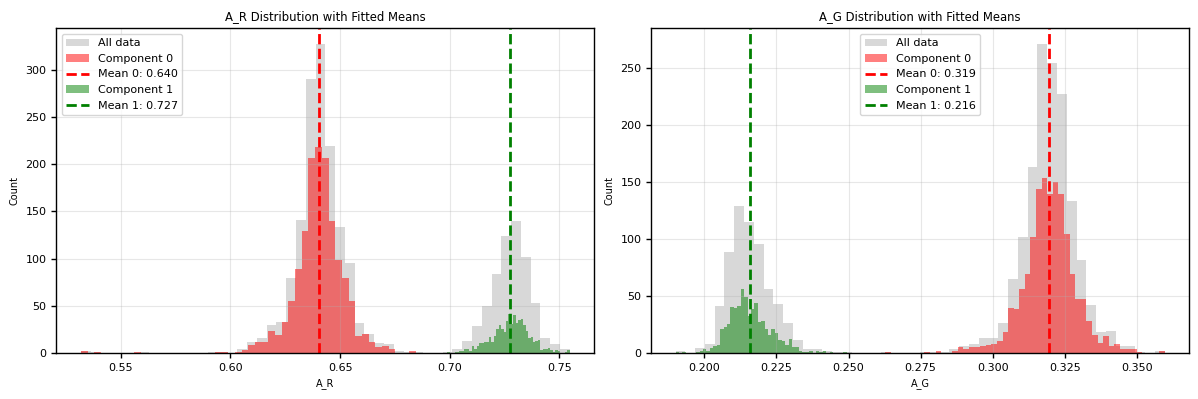


  (Close the plot window to continue)

Fixed means extracted from 2091 high-photon molecules:
  Component 0: A_R=0.6403, A_G=0.3195
  Component 1: A_R=0.7275, A_G=0.2157

These means will be held fixed while analyzing noise at lower photon levels.


In [28]:
# Step 1: Extract reference means from highest-photon data (Analytical Approach)
# Uses all molecules to establish fixed mean positions
# These means represent the true dye RGB signatures (signal), not measurement noise

fixed_means, ref_db, gmm = SM_E.extract_reference_means(
    sm_db[sm_db['photons'] > 25000][sm_db['A_R'] > 0.4][sm_db['A_G'] > 0.1],
    reference_photon_threshold=None,
    n_components=2,
    covariance_type="full",
    fit_type="MLE",
    verbose=True
)

print(f"\nFixed means extracted from {len(ref_db)} high-photon molecules:")
print(f"  Component 0: A_R={fixed_means[0,0]:.4f}, A_G={fixed_means[0,1]:.4f}")
print(f"  Component 1: A_R={fixed_means[1,0]:.4f}, A_G={fixed_means[1,1]:.4f}")
print(f"\nThese means will be held fixed while analyzing noise at lower photon levels.")

Analytical Misidentification Analysis
Photon bins: 19 bins
  Range: 500 - 250,000 photons
Reference molecules: 2091
Fixed means: 2 components

Photon accumulation rows (reference molecules only): 291941

Bin 1/19: [500, 693) photons...
  Molecules in bin: 219
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


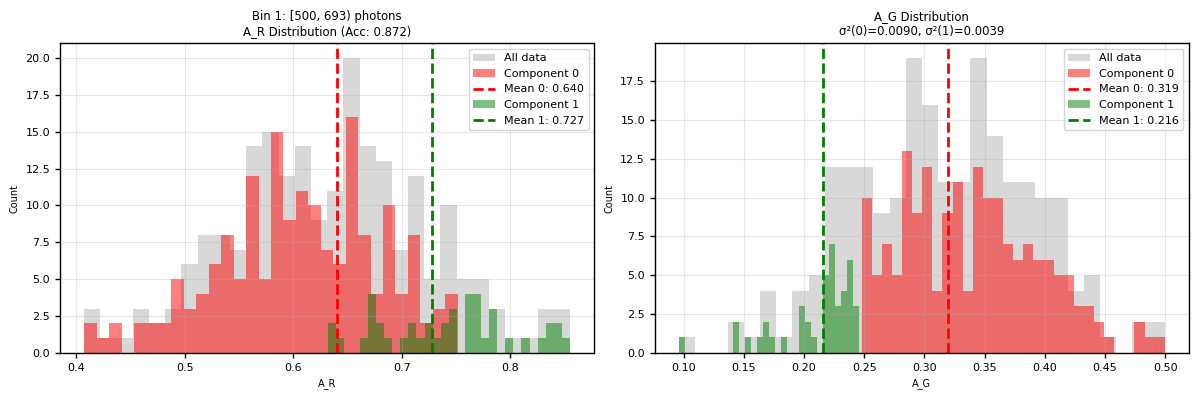

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.872
  Component accuracies: [ 0.90398  0.79374]

Bin 2/19: [693, 962) photons...
  Molecules in bin: 343
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


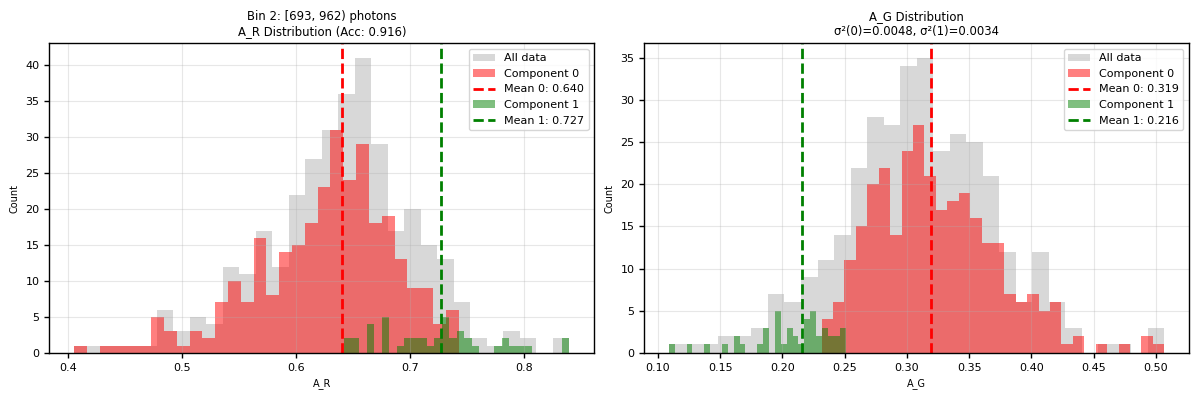

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.916
  Component accuracies: [ 0.95394  0.78002]

Bin 3/19: [962, 1,334) photons...
  Molecules in bin: 432
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


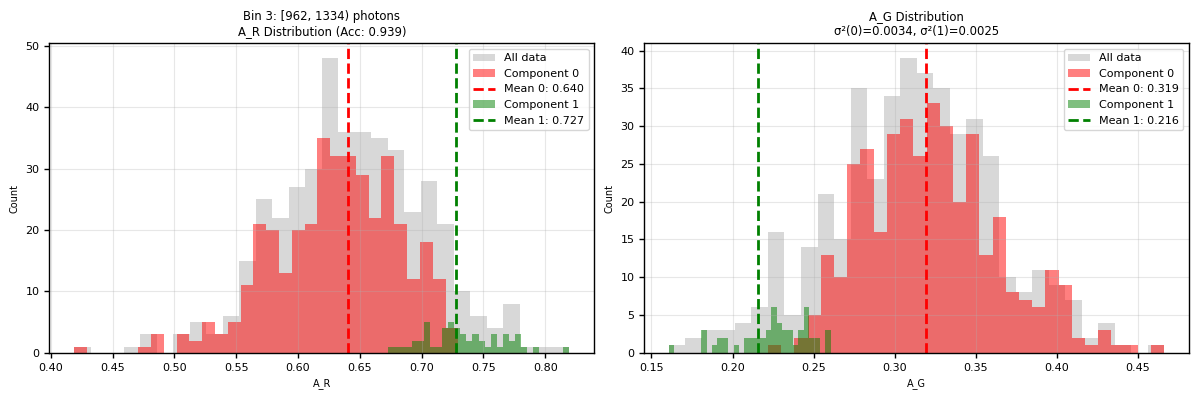

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.939
  Component accuracies: [ 0.96837  0.83105]

Bin 4/19: [1,334, 1,850) photons...
  Molecules in bin: 638
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


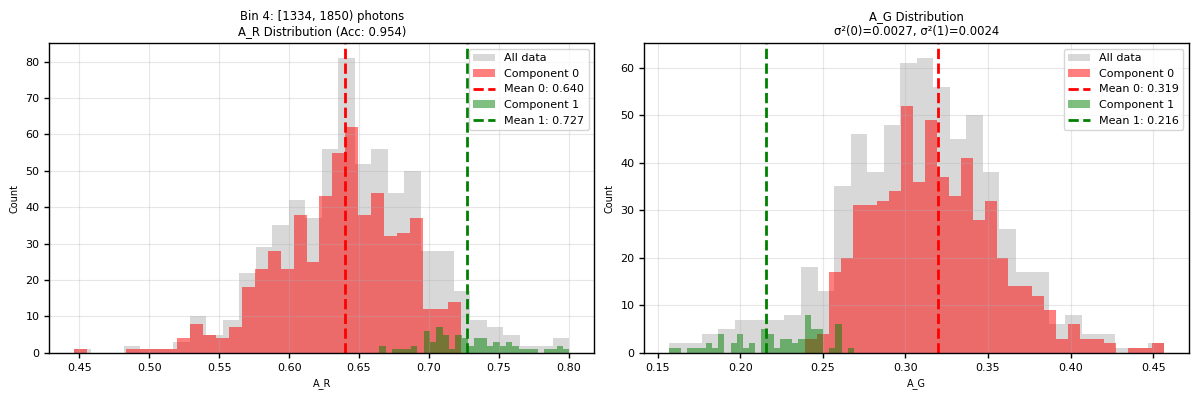

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.954
  Component accuracies: [ 0.97839  0.84028]

Bin 5/19: [1,850, 2,566) photons...
  Molecules in bin: 809
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


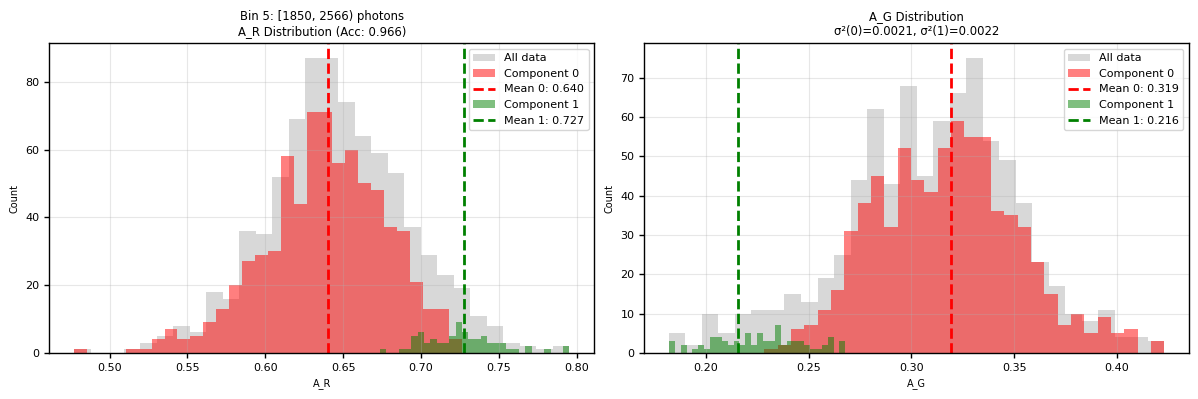

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.966
  Component accuracies: [ 0.98527  0.86711]

Bin 6/19: [2,566, 3,559) photons...
  Molecules in bin: 1114
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


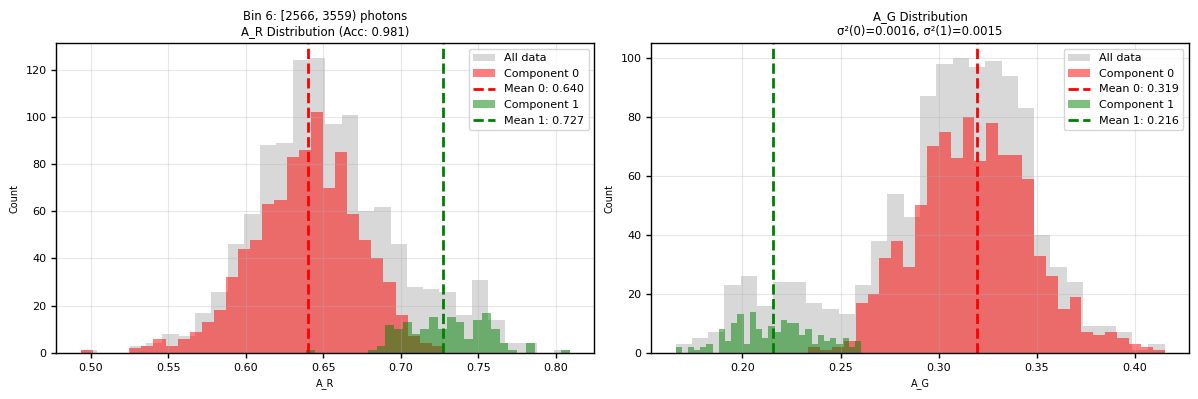

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.981
  Component accuracies: [ 0.99025  0.93831]

Bin 7/19: [3,559, 4,935) photons...
  Molecules in bin: 1341
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


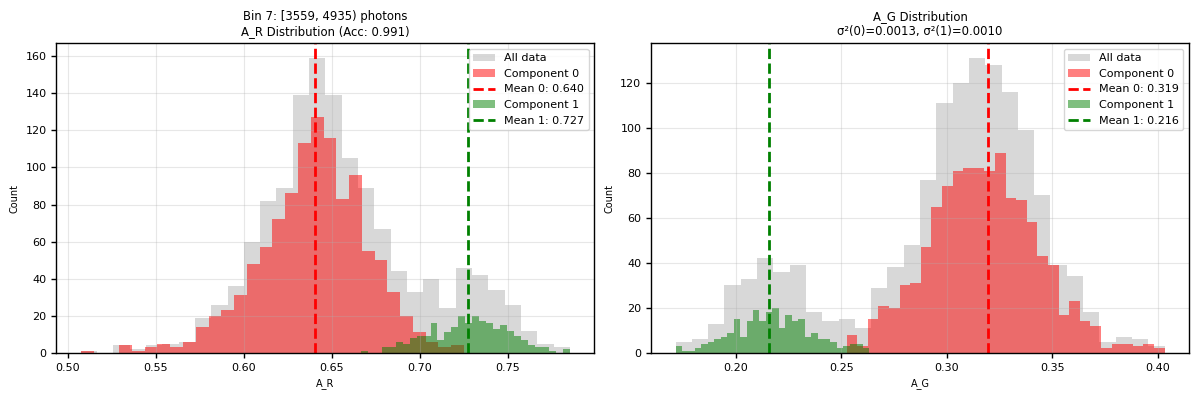

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.991
  Component accuracies: [ 0.99494  0.97737]

Bin 8/19: [4,935, 6,845) photons...
  Molecules in bin: 1540
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


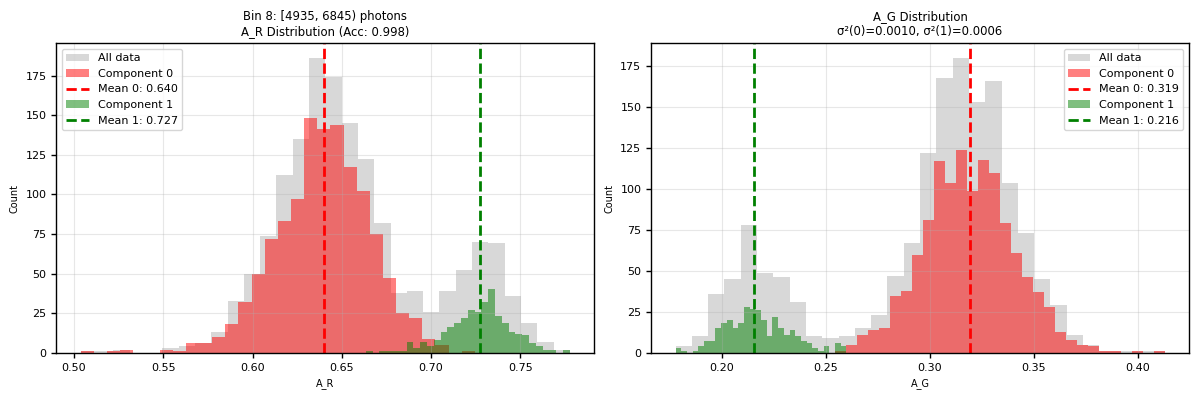

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 0.998
  Component accuracies: [ 0.99891  0.99578]

Bin 9/19: [6,845, 9,494) photons...
  Molecules in bin: 1697
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


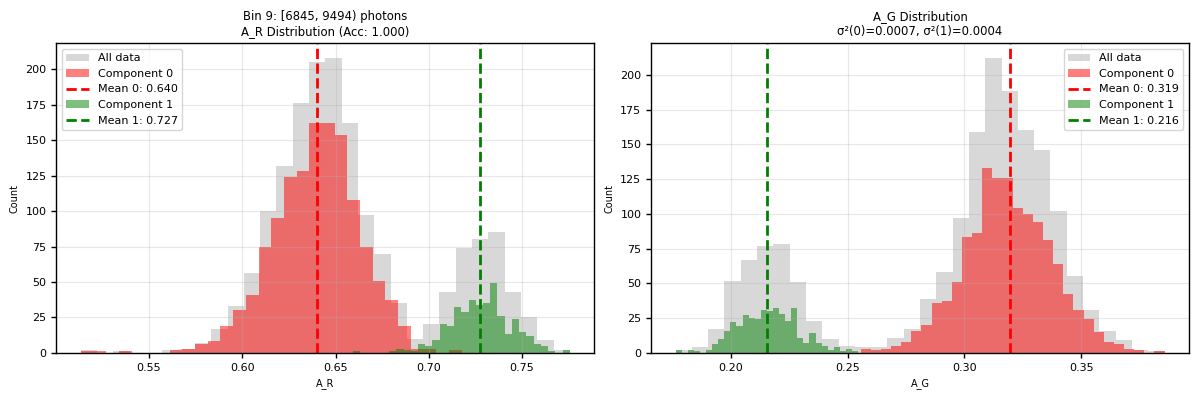

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 0.99983  0.99954]

Bin 10/19: [9,494, 13,167) photons...
  Molecules in bin: 1852
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


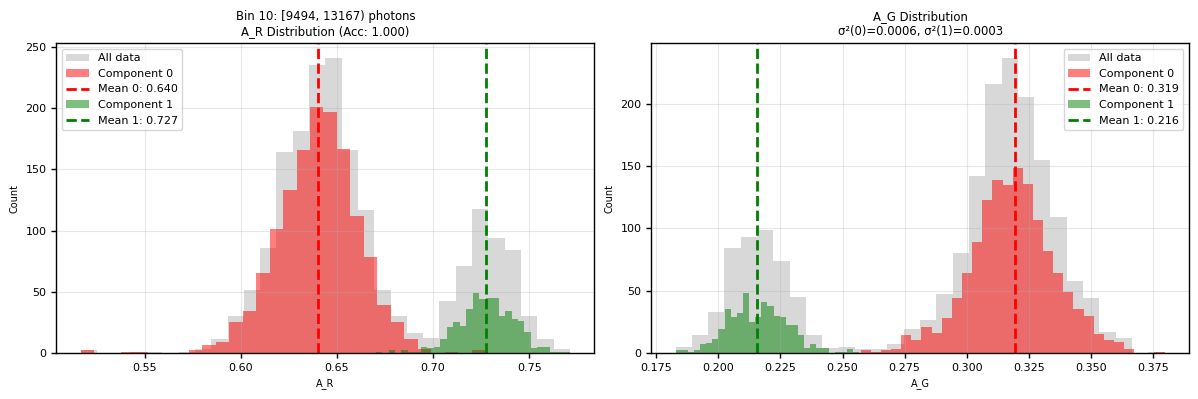

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 0.99996  0.99995]

Bin 11/19: [13,167, 18,261) photons...
  Molecules in bin: 1989
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


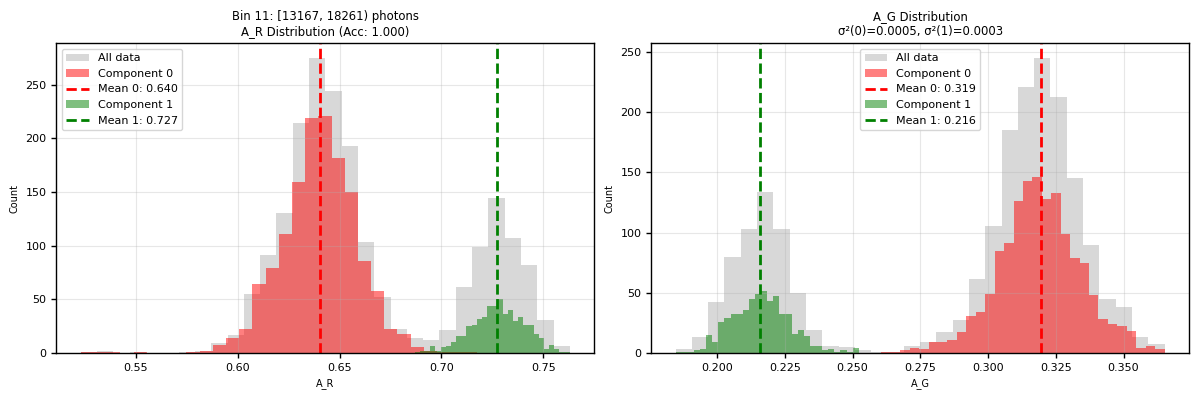

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 0.99999  0.99999]

Bin 12/19: [18,261, 25,327) photons...
  Molecules in bin: 2056
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


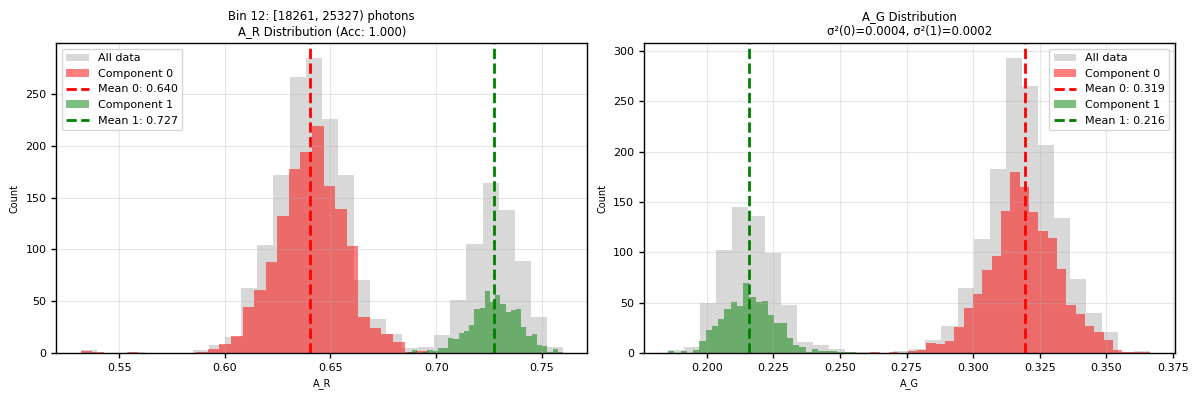

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 13/19: [25,327, 35,126) photons...
  Molecules in bin: 2075
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


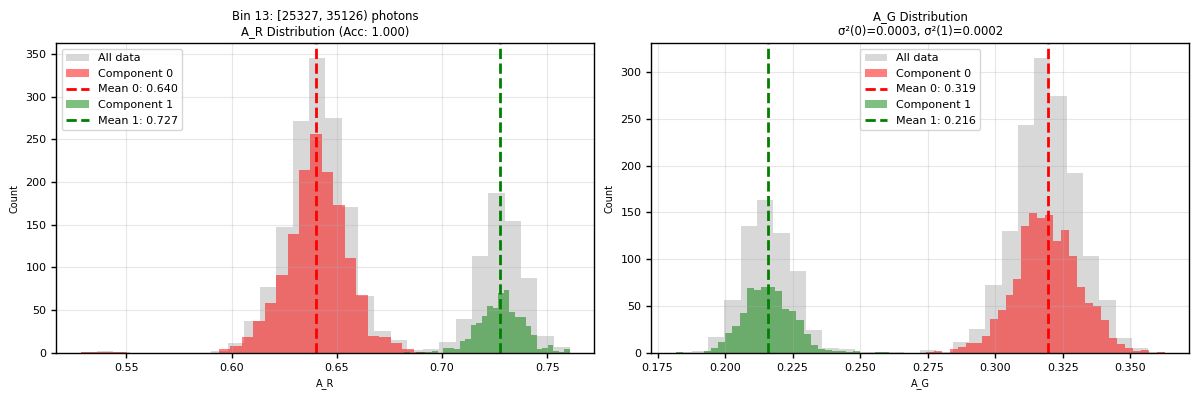

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 14/19: [35,126, 48,717) photons...
  Molecules in bin: 1904
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


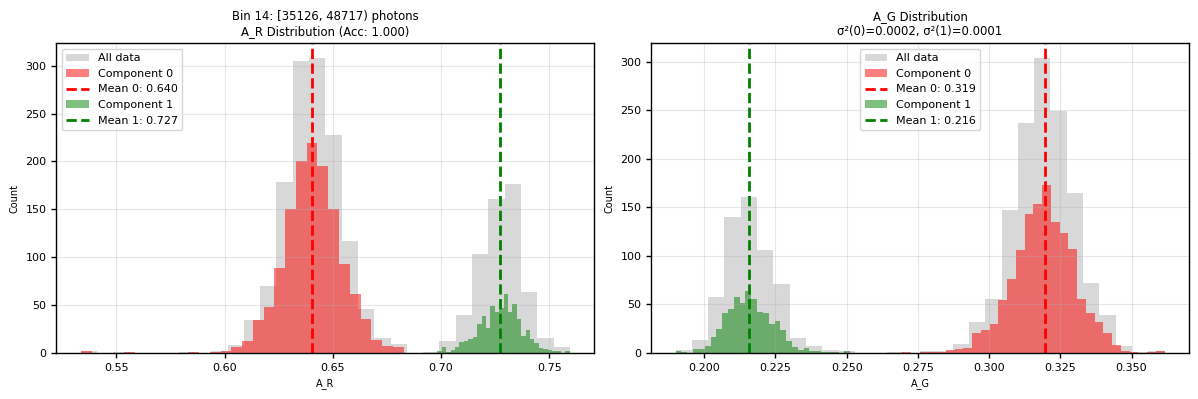

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 15/19: [48,717, 67,567) photons...
  Molecules in bin: 1686
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


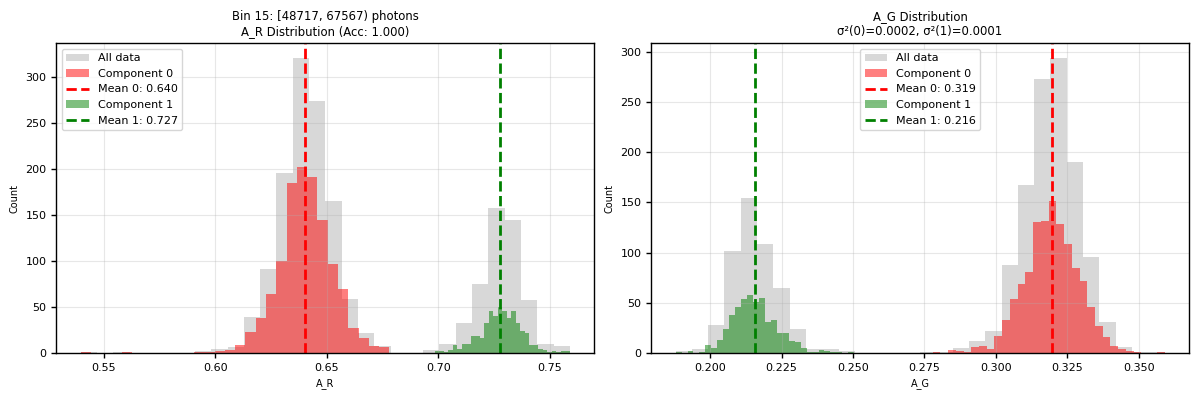

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 16/19: [67,567, 93,710) photons...
  Molecules in bin: 1471
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


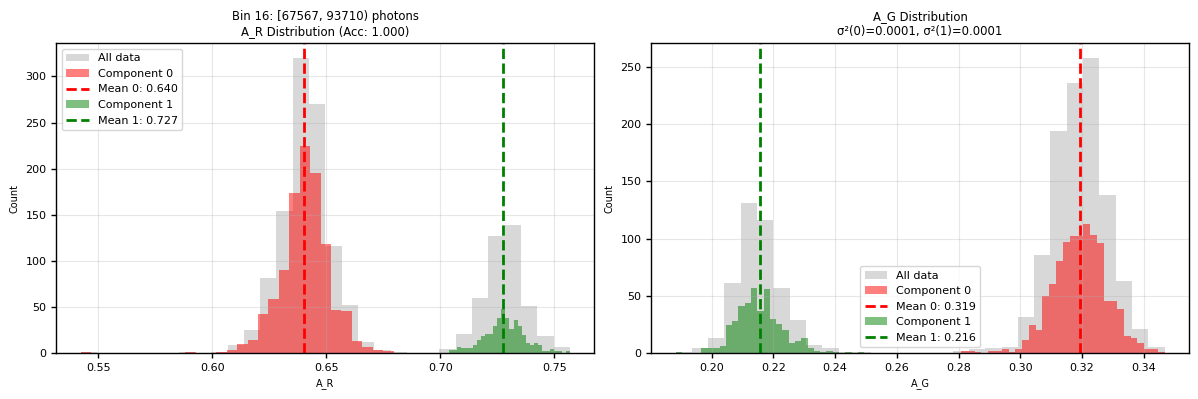

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 17/19: [93,710, 129,968) photons...
  Molecules in bin: 1273
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


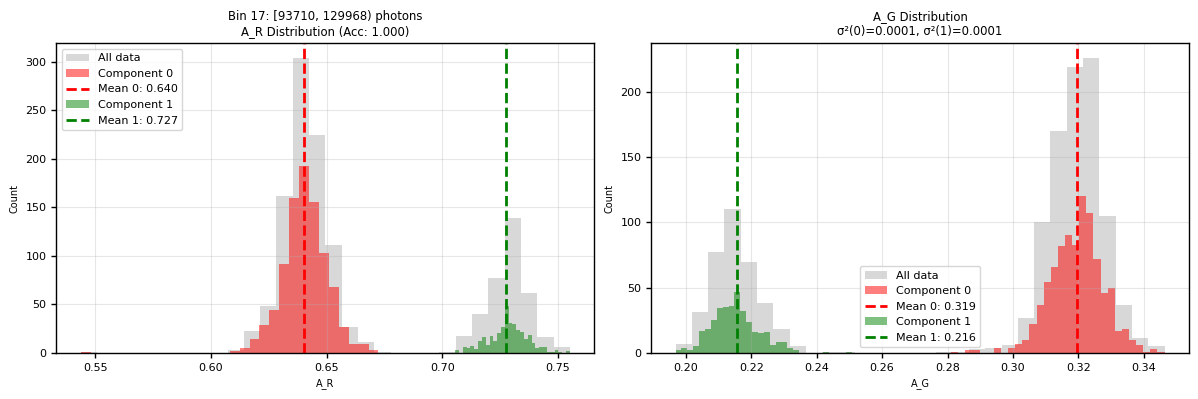

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 18/19: [129,968, 180,256) photons...
  Molecules in bin: 1092
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


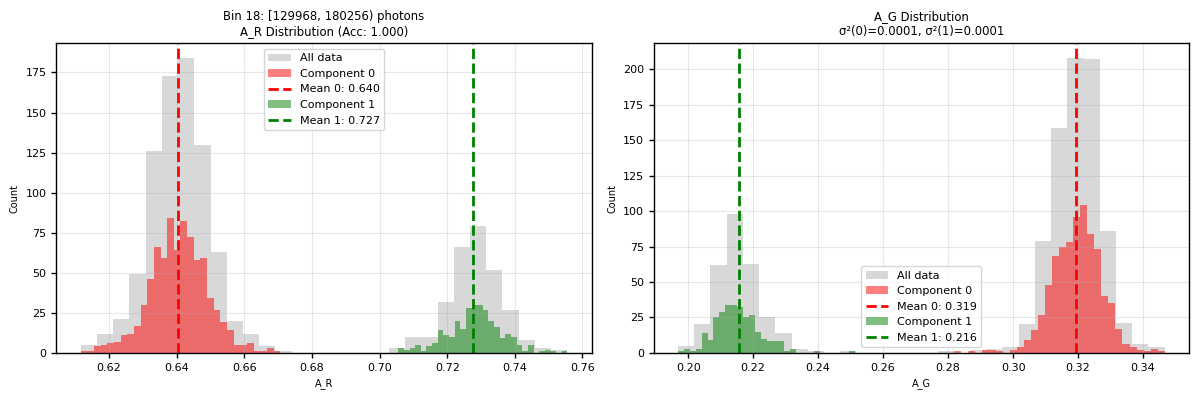

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Bin 19/19: [180,256, 250,000) photons...
  Molecules in bin: 910
  Fitting covariances (M-estimator: tukey)...
  Covariance fitting: converged
  Calculating analytical error rates...


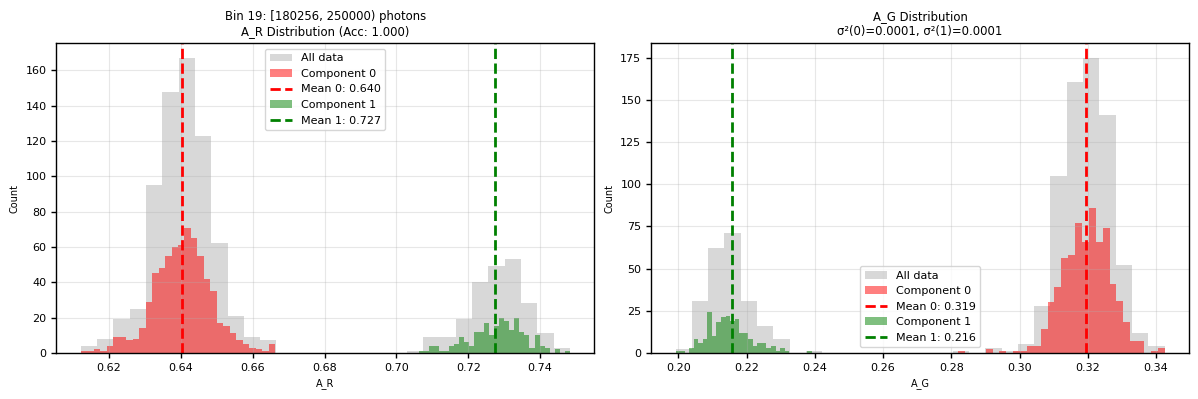

  (Close plot to continue to next bin)
  Overall accuracy (analytical): 1.000
  Component accuracies: [ 1.  1.]

Analytical Analysis Complete!
Summary database: 19 bins
Overall accuracy range: 0.872 - 1.000

Analytical analysis complete:
  Summary: 19 photon bins
  Accuracy range: 0.872 - 1.000


In [29]:
# Step 2: Analytical misidentification analysis across photon bins
# For each photon bin:
#   1. Fit covariances with fixed means (M-estimators) - characterizes measurement noise robustly
#   2. Analytically calculate overlap/error rates from fitted distributions
# This separates signal (means) from noise (covariances) for better interpretation

photon_bins = np.logspace(np.log10(500), np.log10(250000), 20)  # 2k to 200k photons, 20 bins

summary_analytical = SM_E.analyze_photon_dependent_misidentification_analytical(
    pa_db,
    fixed_means,
    ref_db,
    photon_bins,
    reference_covariances=gmm.covariances_,  # Use reference covariances from high-photon fit
    use_earliest_entry=True,
    estimator_type="tukey",  # Use Tukey bisquare (aggressive outlier down-weighting)
    max_iter=20,  # Maximum iterations for M-estimator re-weighting
    n_mc_samples=100000,  # Monte Carlo samples for analytical calculation
    verbose=True
)

print(f"\nAnalytical analysis complete:")
print(f"  Summary: {len(summary_analytical)} photon bins")
print(f"  Accuracy range: {summary_analytical['overall_accuracy'].min():.3f} - {summary_analytical['overall_accuracy'].max():.3f}")


In [30]:
summary_analytical

,photon_bin_min,photon_bin_max,n_molecules,converged,overall_accuracy,overall_error_rate,component_0_accuracy,component_0_error_rate,component_1_accuracy,component_1_error_rate,...,confusion_matrix_10,confusion_matrix_11,cov_0_AR_AR,cov_0_AR_AG,cov_0_AG_AG,weight_0,cov_1_AR_AR,cov_1_AR_AG,cov_1_AG_AG,weight_1
0,500.000000,693.459428,219,True,0.871764,0.128236,0.90398,0.09602,0.79374,0.20626,...,0.20626,0.79374,0.005778,-0.003027,0.003221,0.707763,0.002467,-0.000986,0.001476,0.292237
1,693.459428,961.771957,343,True,0.916418,0.083582,0.95394,0.04606,0.78002,0.21998,...,0.21998,0.78002,0.002836,-0.001511,0.001948,0.784257,0.001678,-0.000540,0.001721,0.215743
2,961.771957,1333.899663,432,True,0.939126,0.060874,0.96837,0.03163,0.83105,0.16895,...,0.16895,0.83105,0.001981,-0.001098,0.001371,0.787037,0.000910,-0.000619,0.001560,0.212963
3,1333.899663,1850.010596,638,True,0.954145,0.045855,0.97839,0.02161,0.84028,0.15972,...,0.15972,0.84028,0.001543,-0.000846,0.001161,0.824451,0.000911,-0.000608,0.001513,0.175549
4,1850.010596,2565.814580,809,True,0.966429,0.033571,0.98527,0.01473,0.86711,0.13289,...,0.13289,0.86711,0.001135,-0.000667,0.000933,0.840544,0.000723,-0.000656,0.001440,0.159456
5,2565.814580,3558.576623,1114,True,0.980832,0.019168,0.99025,0.00975,0.93831,0.06169,...,0.06169,0.93831,0.000926,-0.000525,0.000711,0.818671,0.000648,-0.000502,0.000810,0.181329
6,3558.576623,4935.457021,1341,True,0.991337,0.008663,0.99494,0.00506,0.97737,0.02263,...,0.02263,0.97737,0.000711,-0.000422,0.000551,0.794929,0.000468,-0.000338,0.000508,0.205071
7,4935.457021,6845.078408,1540,True,0.998225,0.001775,0.99891,0.00109,0.99578,0.00422,...,0.00422,0.99578,0.000567,-0.000319,0.000401,0.781169,0.000296,-0.000204,0.000286,0.218831
8,6845.078408,9493.568319,1697,True,0.999763,0.000237,0.99983,0.00017,0.99954,0.00046,...,0.00046,0.99954,0.000437,-0.000240,0.000307,0.767826,0.000238,-0.000141,0.000165,0.232174
9,9493.568319,13166.808917,1852,True,0.999957,0.000043,0.99996,0.00004,0.99995,0.00005,...,0.00005,0.99995,0.000346,-0.000191,0.000242,0.741901,0.000187,-0.000117,0.000136,0.258099


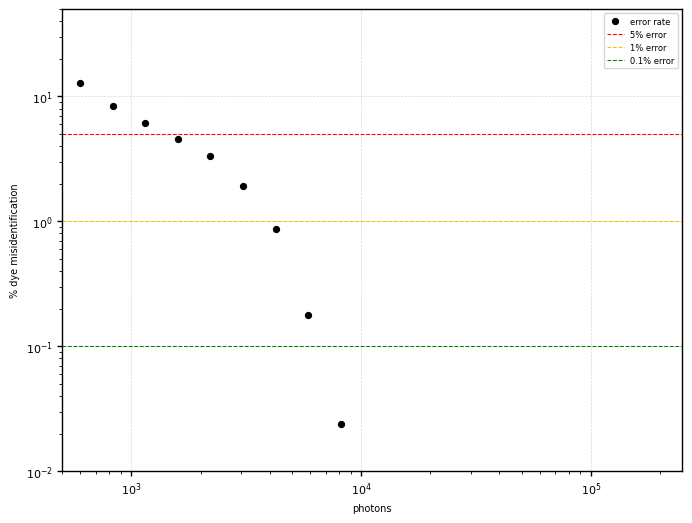

In [32]:
fig, axs = plotter.create_subplots()

axs = plotter.scatter_plot(axs, 0.5*(summary_analytical['photon_bin_min']+summary_analytical['photon_bin_max']), 100*(summary_analytical['overall_error_rate']),
                          xlabel='photons', ylabel=r'% dye misidentification', 
                          label='error rate')

axs.set_ylim([0.01, 50])
axs.hlines(y=5, xmin=500, xmax=250000, ls='--', lw=0.75, color='red', label=r'5% error')
axs.hlines(y=1, xmin=500, xmax=250000, ls='--', lw=0.75, color='#FFBF00', label=r'1% error')
axs.hlines(y=0.1, xmin=500, xmax=250000, ls='--', lw=0.75, color='green', label=r'0.1% error')

axs.set_xlim([500, 250000])

axs.set_yscale('log')
axs.set_xscale('log')
axs.legend(loc='best')
plt.savefig(os.path.join(folder, 'Dye_Error_Rate.svg'), dpi=600, format='svg')

plt.show()

In [ ]:
# Diagnostic: Examine posterior distributions to understand outlier sensitivity
# Let's look at a specific photon bin to understand the fitting quality

# Choose a mid-range photon bin for analysis (e.g., around 10k photons)
test_bin_min = 10000
test_bin_max = 14000

# Filter data for this photon bin
bin_molecules = pa_db[
    (pa_db['molecular_index'].isin(ref_db['molecular_index'])) &
    (pa_db['photons_accumulated'] >= test_bin_min) &
    (pa_db['photons_accumulated'] < test_bin_max)
]

print(f"Analyzing photon bin: [{test_bin_min:,} - {test_bin_max:,}) photons")
print(f"Number of molecules: {len(bin_molecules)}")

# Extract A_R, A_G data
X = bin_molecules[['A_R', 'A_G']].values

# Get reference covariances from high-photon fit
ref_covariances = gmm.covariances_
print(f"\nReference covariances from high-photon fit (>25k photons):")
for k in range(len(fixed_means)):
    det = np.linalg.det(ref_covariances[k])
    print(f"  Component {k}: det={det:.6f}")
    print(f"    {ref_covariances[k]}")

# Fit covariances with fixed means using EM (standard approach)
covs_em, weights_em, converged_em = SM_E.fit_covariances_fixed_means(
    X, fixed_means, fit_type="EM", max_iter=100, verbose=True
)

print(f"\nFitted covariances at {test_bin_min:,}-{test_bin_max:,} photons (EM):")
for k in range(len(fixed_means)):
    det = np.linalg.det(covs_em[k])
    print(f"  Component {k}: det={det:.6f}")
    print(f"    {covs_em[k]}")

# Calculate determinant ratios
print(f"\nDeterminant ratios (low-photon / high-photon):")
for k in range(len(fixed_means)):
    ratio = np.linalg.det(covs_em[k]) / np.linalg.det(ref_covariances[k])
    print(f"  Component {k}: {ratio:.1f}x larger")

# Calculate posterior probabilities (responsibilities)
from scipy.stats import multivariate_normal
n_components = len(fixed_means)
responsibilities = np.zeros((len(X), n_components))

for k in range(n_components):
    responsibilities[:, k] = weights_em[k] * multivariate_normal.pdf(
        X, mean=fixed_means[k], cov=covs_em[k]
    )

# Normalize responsibilities
responsibilities /= responsibilities.sum(axis=1, keepdims=True)

# Get maximum posterior probability for each point
max_posteriors = responsibilities.max(axis=1)

# Visualize posterior distribution
fig, axs = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Histogram of maximum posterior probabilities
axs[0, 0].hist(max_posteriors, bins=50, edgecolor='black')
axs[0, 0].axvline(0.8, color='red', linestyle='--', label='80% confidence')
axs[0, 0].set_xlabel('Maximum Posterior Probability')
axs[0, 0].set_ylabel('Count')
axs[0, 0].set_title('Distribution of Assignment Confidence')
axs[0, 0].legend()

# Plot 2: Data colored by confidence
scatter = axs[0, 1].scatter(X[:, 0], X[:, 1], c=max_posteriors, cmap='viridis', 
                            s=10, alpha=0.5)
axs[0, 1].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20, 
               label='Fixed means')
axs[0, 1].set_xlabel('A_R')
axs[0, 1].set_ylabel('A_G')
axs[0, 1].set_title('Data colored by posterior confidence')
axs[0, 1].legend()
plt.colorbar(scatter, ax=axs[0, 1], label='Max posterior')

# Plot 3: Reference covariances from high-photon fit
from matplotlib.patches import Ellipse
def plot_cov_ellipse(cov, pos, ax, n_std=2.0, **kwargs):
    """Plot covariance ellipse"""
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=pos, width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellipse)

axs[0, 2].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, 2], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'Ref cov {k}')
axs[0, 2].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[0, 2].set_xlabel('A_R')
axs[0, 2].set_ylabel('A_G')
axs[0, 2].set_title(f'Reference Covariances (high-photon fit)')
axs[0, 2].legend()

# Plot 4: Fitted covariances (EM) - showing the problem
axs[1, 0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[1, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM cov {k}')
axs[1, 0].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[1, 0].set_xlabel('A_R')
axs[1, 0].set_ylabel('A_G')
axs[1, 0].set_title('Fitted Covariances (EM) - Current Method')
axs[1, 0].legend()

# Plot 5: Overlay both for comparison
axs[1, 1].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    # Reference (dashed)
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[1, 1], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, linestyle='--', label=f'Ref {k}')
    # Fitted (solid)
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[1, 1], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM {k}')
axs[1, 1].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20,
               label='Fixed means')
axs[1, 1].set_xlabel('A_R')
axs[1, 1].set_ylabel('A_G')
axs[1, 1].set_title('Comparison: Reference (dashed) vs EM (solid)')
axs[1, 1].legend()

# Plot 6: Identify potential outliers using Mahalanobis distance from reference
outliers_mask = np.zeros(len(X), dtype=bool)
mahal_threshold = 3.0  # 3-sigma threshold

for i, x in enumerate(X):
    # Find closest component
    dists = []
    for k in range(n_components):
        diff = x - fixed_means[k]
        inv_cov = np.linalg.inv(ref_covariances[k])
        mahal = np.sqrt(diff @ inv_cov @ diff)
        dists.append(mahal)
    
    min_dist = min(dists)
    if min_dist > mahal_threshold:
        outliers_mask[i] = True

axs[1, 2].scatter(X[~outliers_mask, 0], X[~outliers_mask, 1], alpha=0.3, s=10, c='blue',
                  label=f'Inliers (<{mahal_threshold}σ from ref)')
axs[1, 2].scatter(X[outliers_mask, 0], X[outliers_mask, 1], alpha=0.8, s=30, c='red',
                  label=f'Outliers (>{mahal_threshold}σ from ref)')
for k in range(n_components):
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[1, 2], n_std=mahal_threshold,
                     edgecolor='green', facecolor='none', 
                     linewidth=2, linestyle='--')
axs[1, 2].plot(fixed_means[:, 0], fixed_means[:, 1], 'k*', markersize=20,
               label='Fixed means')
axs[1, 2].set_xlabel('A_R')
axs[1, 2].set_ylabel('A_G')
axs[1, 2].set_title(f'Outlier Detection using Mahalanobis (n={outliers_mask.sum()})')
axs[1, 2].legend()

plt.show()

# Statistics
print(f"\nPosterior Statistics:")
print(f"  Mean max posterior: {max_posteriors.mean():.3f}")
print(f"  Median max posterior: {np.median(max_posteriors):.3f}")
print(f"  % with >90% confidence: {100*(max_posteriors > 0.9).sum()/len(max_posteriors):.1f}%")
print(f"  % with >80% confidence: {100*(max_posteriors > 0.8).sum()/len(max_posteriors):.1f}%")
print(f"  % with <50% confidence: {100*(max_posteriors < 0.5).sum()/len(max_posteriors):.1f}%")
print(f"\nOutlier Statistics (Mahalanobis distance from reference):")
print(f"  % outliers (>{mahal_threshold}σ): {100*outliers_mask.sum()/len(outliers_mask):.1f}%")

In [ ]:
# Test robust fitting method and compare with standard EM
print("="*60)
print("Testing Robust Fitting Method")
print("="*60)

# Test with different Mahalanobis thresholds
thresholds = [2.0, 3.0, 4.0]

fig, axs = plt.subplots(2, len(thresholds)+1, figsize=(6*(len(thresholds)+1), 12))

# Plot 0: Standard EM (for comparison)
axs[0, 0].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
for k in range(n_components):
    plot_cov_ellipse(covs_em[k], fixed_means[k], axs[0, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=2, label=f'EM {k}')
    # Also show reference as dashed
    plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, 0], n_std=2.0,
                     edgecolor=['blue', 'orange'][k], facecolor='none', 
                     linewidth=1, linestyle='--', alpha=0.5)
axs[0, 0].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20)
axs[0, 0].set_xlabel('A_R')
axs[0, 0].set_ylabel('A_G')
axs[0, 0].set_title('Standard EM\n(dashed = reference)')
axs[0, 0].legend()

# Determinant comparison
dets_em = [np.linalg.det(covs_em[k]) for k in range(n_components)]
dets_ref = [np.linalg.det(ref_covariances[k]) for k in range(n_components)]
ratios_em = [dets_em[k] / dets_ref[k] for k in range(n_components)]

axs[1, 0].bar([f'Comp {k}' for k in range(n_components)], ratios_em, color=['blue', 'orange'])
axs[1, 0].axhline(1.0, color='green', linestyle='--', label='Reference')
axs[1, 0].set_ylabel('Det ratio (fitted / ref)')
axs[1, 0].set_title('Standard EM: Covariance Size Ratio')
axs[1, 0].legend()

# Test robust fitting with different thresholds
for i, threshold in enumerate(thresholds, 1):
    print(f"\nTesting threshold = {threshold}σ:")
    
    covs_robust, weights_robust, converged_robust = SM_E.fit_covariances_fixed_means_robust(
        X, fixed_means, 
        reference_covariances=ref_covariances,
        mahalanobis_threshold=threshold,
        max_iter=10,
        verbose=True
    )
    
    # Plot fitted covariances
    axs[0, i].scatter(X[:, 0], X[:, 1], alpha=0.2, s=5, c='gray')
    for k in range(n_components):
        plot_cov_ellipse(covs_robust[k], fixed_means[k], axs[0, i], n_std=2.0,
                         edgecolor=['blue', 'orange'][k], facecolor='none', 
                         linewidth=2, label=f'Robust {k}')
        # Also show reference as dashed
        plot_cov_ellipse(ref_covariances[k], fixed_means[k], axs[0, i], n_std=2.0,
                         edgecolor=['blue', 'orange'][k], facecolor='none', 
                         linewidth=1, linestyle='--', alpha=0.5)
    axs[0, i].plot(fixed_means[:, 0], fixed_means[:, 1], 'r*', markersize=20)
    axs[0, i].set_xlabel('A_R')
    axs[0, i].set_ylabel('A_G')
    axs[0, i].set_title(f'Robust ({threshold}σ threshold)\n(dashed = reference)')
    axs[0, i].legend()
    
    # Determinant comparison
    dets_robust = [np.linalg.det(covs_robust[k]) for k in range(n_components)]
    ratios_robust = [dets_robust[k] / dets_ref[k] for k in range(n_components)]
    
    axs[1, i].bar([f'Comp {k}' for k in range(n_components)], ratios_robust, color=['blue', 'orange'])
    axs[1, i].axhline(1.0, color='green', linestyle='--', label='Reference')
    axs[1, i].set_ylabel('Det ratio (fitted / ref)')
    axs[1, i].set_title(f'Robust ({threshold}σ): Covariance Size Ratio')
    axs[1, i].legend()

plt.show()

print("\n" + "="*60)
print("Summary: Determinant Ratios (Fitted / Reference)")
print("="*60)
print(f"{'Method':<20} {'Component 0':<15} {'Component 1':<15}")
print("-"*60)
print(f"{'Standard EM':<20} {ratios_em[0]:<15.2f} {ratios_em[1]:<15.2f}")
for threshold in thresholds:
    covs_robust, _, _ = SM_E.fit_covariances_fixed_means_robust(
        X, fixed_means, ref_covariances, threshold, max_iter=10, verbose=False
    )
    dets = [np.linalg.det(covs_robust[k]) for k in range(n_components)]
    ratios = [dets[k] / dets_ref[k] for k in range(n_components)]
    print(f"{'Robust (' + str(threshold) + 'σ)':<20} {ratios[0]:<15.2f} {ratios[1]:<15.2f}")

print("\nIdeal ratio should be close to 1.0 (matching reference covariances)")
print("Lower ratios = tighter fit, less influenced by outliers")

In [ ]:
# different implementation: take the highest photon data and get the centres, then fit the widths at each photon bin.
# Then use the fact the data are normally distributed to calculate the analytical false positive rates.

# this is an example of linking molecules with HDBSCAN ###

In [ ]:
single_molecule_database, single_frame_database = SM_E.extract_single_molecules_HDBSCAN(
    localisation_files,
    min_cluster_size=min_cluster_size,
    max_localization_error=max_localization_error,
    min_photons=min_photons,
    max_photons=max_photons,
)

# this is an example of linking molecules with DBSCAN

In [ ]:
single_molecule_database, single_frame_database = SM_E.extract_single_molecules_DBSCAN(
    pd.read_hdf(localisation_files[0]),
    min_cluster_size=min_cluster_size,
    max_localization_error=max_localization_error,Dye
    min_photons=min_photons,
    chi_val=chi_val,
    max_photons=max_photons,
)

In [ ]:
molecules_to_remove = single_molecule_database['molecular_index'][single_molecule_database['A_R'] > 0.8]

In [ ]:
single_molecule_database = single_molecule_database[single_molecule_database['A_R'] < 0.8]
single_frame_database =

In [ ]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])



plt.hist((single_molecule_database['A_R']), 200);
plt.show()

# this is an example of linking molecules sequentially

In [ ]:
extract_single_molecules_linked = SM_E.extract_single_molecules_linked(
    localisation_files,
    max_distance=max_distance,
    max_localization_error=max_localization_error,
    min_photons=min_photons,
    max_photons=max_photons,
)